In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import pickle

In [2]:
file_path = "debug_output/mask.npy" 
data = np.load(file_path, allow_pickle=True)

In [3]:
data.shape


(4, 1024, 1024)

TypeError: Invalid shape (4, 1024, 1024) for image data

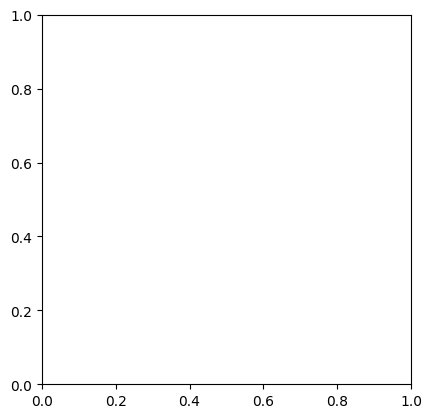

In [4]:
layer_0 = data

plt.imshow(layer_0, cmap='gray')  # Use 'gray' colormap for better contrast
plt.colorbar(label="Pixel Intensity")  # Add a color bar

In [15]:
dat_path = "model_output/file_map.dat"

with open(dat_path, "rb") as file:
    file_map = pickle.load(file)

print(type(file_map))

patches_path = []
for map in file_map:
    print(map[1])
    patches_path.append(map[1])


<class 'list'>
/Users/gk/Desktop/TissueLab/Tissuelab-Model-Zoo/tissue_segmentation/TIA_breast_cancer/model_output/0
/Users/gk/Desktop/TissueLab/Tissuelab-Model-Zoo/tissue_segmentation/TIA_breast_cancer/model_output/1
/Users/gk/Desktop/TissueLab/Tissuelab-Model-Zoo/tissue_segmentation/TIA_breast_cancer/model_output/2
/Users/gk/Desktop/TissueLab/Tissuelab-Model-Zoo/tissue_segmentation/TIA_breast_cancer/model_output/3


In [16]:
mask_patches = []

for path in patches_path:
    patch = np.load(path + ".raw.0.npy")
    mask_patches.append(patch[:, :, 0])

In [17]:
len(mask_patches[0])


1024

In [10]:
def patch_concat_mask(masks_np: list[np.ndarray], original_wh: tuple[int,int], patch_size:int, grid_size: tuple[int,int]):
    """
    masks_np: list of (1024,1024) numpy, range=0/255
    original_wh: (w,h) => region.width, region.height
    grid_size: (n_rows, n_cols)
    """
    w,h = original_wh
    # padded
    new_w = ((w+patch_size-1)//patch_size)*patch_size
    new_h = ((h+patch_size-1)//patch_size)*patch_size
    bigmask=np.zeros((new_h, new_w), dtype=np.uint8)

    idx=0
    rows,cols=grid_size
    for row in range(rows):
        for col in range(cols):
            if idx<len(masks_np):
                pm = masks_np[idx]  # shape=(1024,1024)
                x=col*patch_size
                y=row*patch_size
                # bigmask[y:y+patch_size, x:x+patch_size]=pm
                bigmask[y:y+patch_size, x:x+patch_size] = pm * 255 if pm.max() <= 1 else pm

                idx+=1
    # crop back
    bigmask=bigmask[:h, :w]
    return bigmask

In [82]:
import numpy as np
import cv2

# def patch_concat_mask_smooth(masks_np: list[np.ndarray], original_wh: tuple[int, int], patch_size: int, grid_size: tuple[int, int], overlap=0.2):

#     w, h = original_wh
#     stride = int(patch_size * (1 - overlap))  

#     new_w = ((w + patch_size - 1) // patch_size) * patch_size
#     new_h = ((h + patch_size - 1) // patch_size) * patch_size

#     bigmask = np.zeros((new_h, new_w), dtype=np.float32)
#     weight_map = np.zeros((new_h, new_w), dtype=np.float32)  #

#     idx = 0
#     rows, cols = grid_size
#     for row in range(rows):
#         for col in range(cols):
#             if idx < len(masks_np):
#                 pm = masks_np[idx].astype(np.float32) 
#                 if pm.max() <= 1:
#                     pm *= 255 
                
#                 x, y = col * stride, row * stride 

#                 weight_patch = np.ones((patch_size, patch_size), dtype=np.float32)

#                 for i in range(patch_size):
#                     for j in range(patch_size):
#                         weight_patch[i, j] *= min(i, patch_size - i - 1, j, patch_size - j - 1) + 1

#                 weight_patch /= weight_patch.max()

#                 bigmask[y:y+patch_size, x:x+patch_size] += pm * weight_patch
#                 weight_map[y:y+patch_size, x:x+patch_size] += weight_patch

#                 idx += 1

#     weight_map = np.maximum(weight_map, 1e-5)
    
#     bigmask /= weight_map

#     bigmask = bigmask[:h, :w].astype(np.uint8)

#     return bigmask

def patch_concat_mask_smooth(masks_np: list[np.ndarray], original_wh: tuple[int, int], 
                      patch_size: int, grid_size: tuple[int, int], extend: int = 64, overlap: float=0.2):
    """
    Concatenates patches with blending to reduce black boundaries.
    
    masks_np: List of (patch_size, patch_size) numpy arrays (0-255 range).
    original_wh: (w, h) = (original image width, height).
    grid_size: (n_rows, n_cols) of patches.
    overlap: Overlap size in pixels to blend patches.
    """
    w, h = original_wh
    stride = int(patch_size * (1 - overlap))  # Define stride based on overlap percentage

    # Compute padded image size
    new_w = ((w + patch_size - 1) // patch_size) * patch_size
    new_h = ((h + patch_size - 1) // patch_size) * patch_size
    
    # Create large blending map
    bigmask = np.zeros((new_h + 2 * extend, new_w + 2 * extend), dtype=np.float32)
    weight_map = np.zeros((new_h + 2 * extend, new_w + 2 * extend), dtype=np.float32)

    idx = 0
    rows, cols = grid_size

    for row in range(rows):
        for col in range(cols):
            if idx < len(masks_np):
                pm = masks_np[idx].astype(np.float32)  # Convert patch to float32
                
                if pm.max() <= 1:  
                    pm *= 255  # Scale if needed
                
                # Extend patch using reflection padding
                pm_extended = cv2.copyMakeBorder(pm, extend, extend, extend, extend, 
                                                 borderType=cv2.BORDER_REFLECT_101)

                # Weight patch for blending
                weight_patch = np.ones((patch_size, patch_size), dtype=np.float32)

                for i in range(patch_size):
                    for j in range(patch_size):
                        weight_patch[i, j] *= min(i, patch_size - i - 1, j, patch_size - j - 1) + 1

                weight_patch /= weight_patch.max()  # Normalize weight map

                # Calculate correct placement coordinates
                x, y = col * stride + extend, row * stride + extend

                # Accumulate results
                bigmask[y:y+patch_size, x:x+patch_size] += pm * weight_patch
                weight_map[y:y+patch_size, x:x+patch_size] += weight_patch

                idx += 1

    # Avoid division by zero in weight_map
    weight_map[weight_map == 0] = 1

    # Blend images using weight_map
    bigmask /= weight_map

    # Convert back to uint8
    # bigmask = np.clip(bigmask, 0, 255).astype(np.uint8)

    # Crop back to original size starting from (extend, extend)
    bigmask = bigmask[extend:extend+h, extend:extend+w]

    return bigmask

In [85]:
bigmask = patch_concat_mask(mask_patches, (2400, 2400), 1024, (2, 2))
bigmask_smooth = patch_concat_mask_smooth(mask_patches, (2400, 2400), 1024, (2, 2))

In [72]:
type(bigmask[0][0])
bigmask[0][0]

15

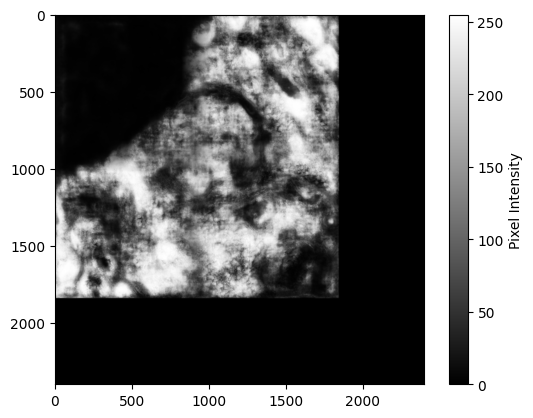

In [86]:
plt.imshow(bigmask_smooth, cmap='gray')  # Use 'gray' colormap for better contrast
plt.colorbar(label="Pixel Intensity")  # Add a color bar


In [62]:
import cv2

def binary_mask(mask_array, threshold=255*0.5):
    return (mask_array > threshold).astype(np.uint8)

def binary_mask_to_polygons(binary_mask):
    contours, _ = cv2.findContours(binary_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    polygons = []
    for contour in contours:
        polygon = contour.reshape(-1, 2).tolist()
        if len(polygon) >= 2:  # Only add polygons with at least 10 points
            polygons.append(polygon)
    return polygons

def mask_to_polygons(mask_array, threshold=255*0.5):
    binm = binary_mask(mask_array, threshold)
    return binary_mask_to_polygons(binm)

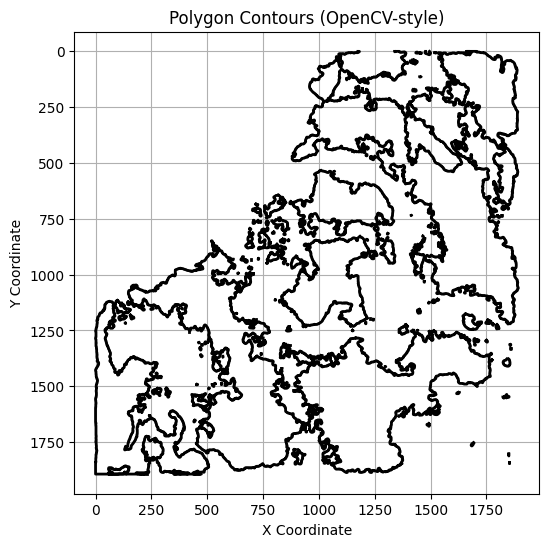

In [67]:
import numpy as np
import matplotlib.pyplot as plt

def plot_polygons(polygons, image_shape=None):
    plt.figure(figsize=(6, 6))

    for polygon in polygons:
        polygon = np.array(polygon)  # Convert list to NumPy array
        plt.plot(polygon[:, 0], polygon[:, 1], color='black', linewidth=2)  # Draw contours

    # Flip Y-axis to match OpenCV's origin (top-left)
    if image_shape:
        plt.ylim(image_shape[0], 0)  # Invert Y-axis range

    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.title("Polygon Contours (OpenCV-style)")
    plt.grid(True)
    plt.axis("equal")  # Keep aspect ratio correct
    plt.show()

# Example usage with your mask
polygons = mask_to_polygons(bigmask_smooth)  # Get polygons from mask
image_shape = bigmask.shape  # Get original image/mask dimensions
plot_polygons(polygons, image_shape)

In [1]:
import uvicorn
import argparse
import os
import sys
import json
import h5py
import torch
import cv2
import numpy as np
import requests
from PIL import Image
from fastapi import FastAPI
from typing import Dict, Any
from pathlib import Path

import logging
import warnings

if logging.getLogger().hasHandlers():
    logging.getLogger().handlers.clear()

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import torch
from matplotlib import cm

from tiatoolbox import logger
from tiatoolbox.models.architecture.unet import UNetModel
from tiatoolbox.models.engine.semantic_segmentor import (
    IOSegmentorConfig,
    SemanticSegmentor,
)
from tiatoolbox.utils.misc import download_data, imread
from tiatoolbox.utils.visualization import overlay_prediction_mask
from tiatoolbox.wsicore.wsireader import WSIReader

|2025-03-17|15:41:42.217| [WARNING] /opt/anaconda3/envs/tiatoolbox/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm

|2025-03-17|15:41:44.434| [WARNING] /opt/anaconda3/envs/tiatoolbox/lib/python3.9/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.21). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()



In [2]:
MODEL = SemanticSegmentor(
        pretrained_model="fcn_resnet50_unet-bcss",
        num_loader_workers=4,
        batch_size=4,
        auto_generate_mask=False,
        )

|2025-03-17|15:42:04.608| [WARNING] /opt/anaconda3/envs/tiatoolbox/lib/python3.9/site-packages/tiatoolbox/models/architecture/__init__.py:149: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

In [ ]:
patch_size = 1024

model_output = MODEL.predict(
    [patch_path],
    save_dir=output_dir,
    mode="tile",
    resolution=1.0,
    units="baseline",
    patch_input_shape=[patch_size, patch_size],
    # patch_output_shape=[patch_size, patch_size],
    # stride_shape=[512, 512],
    device=DEVICE,
    crash_on_exception=True,
)

In [ ]:
def read_wsi_to_patches(wsi_path, bbox, patch_size=1024):
    import tiffslide
    import time
    from concurrent.futures import ThreadPoolExecutor
    """
    read WSI using parallel processing
    """
    svs = tiffslide.TiffSlide(wsi_path)
    target_downsample = DOWNSAMPLE_RATE
    print(target_downsample, DOWNSAMPLE_RATE)
    best_level = find_best_level(svs, target_downsample)

    x_start, y_start, width, height = bbox
    downsample_factor = svs.level_downsamples[best_level]
    scaled_width = int(width / downsample_factor)
    scaled_height = int(height / downsample_factor)

    n_cols = scaled_width // patch_size
    n_rows = scaled_height // patch_size

    print(f"Best Level: {best_level}, Downsample Factor: {downsample_factor}")
    print(f"Scaled Size: {scaled_width}x{scaled_height}, Patches: {n_rows}x{n_cols}")

    processed_patches = []
    start_time = time.time()

    # modified; recreate the dir to store patches
    output_dir = "patches"

    if os.path.exists(output_dir):
        shutil.rmtree(output_dir) 

    os.makedirs(output_dir, exist_ok=True)
    #

    with ThreadPoolExecutor() as executor:
        futures = []
        for row in range(n_rows):
            for col in range(n_cols):
                x = x_start + col * patch_size * downsample_factor
                y = y_start + row * patch_size * downsample_factor
                futures.append(executor.submit(process_patch, svs, x, y, best_level, patch_size))

        for i, future in enumerate(futures):
            processed_patches.append(future.result())

            # modified, save patches as images
            img = Image.fromarray(future.result())
            patch_filename = os.path.join(output_dir, f"patch_{i}.png")
            img.save(patch_filename)

            processed_patches.append(patch_filename)
            # now the output processed_patches is list of patch filenames

    # Save only the final full image
    full_img = svs.read_region((x_start, y_start), level=best_level, size=(scaled_width, scaled_height))
    full_img.save("full_wsi_image.png")

    end_time = time.time()
    print(f"Processing time: {end_time - start_time:.2f} seconds")

    return processed_patches, (n_rows, n_cols), (scaled_width, scaled_height)